#  Supervised Learning

**Thema:** Build a diabetes prediction system using Logistic Regression and Linear Regression.

**Dataset:** `diabetes.csv` — 768 patients with 8 features + 1 target variable (Outcome).

| Feature | Description |
|---|---|
| Pregnancies | Number of pregnancies |
| Glucose | Plasma glucose concentration |
| BloodPressure | Diastolic blood pressure (mm Hg) |
| SkinThickness | Triceps skin fold thickness (mm) |
| Insulin | 2-hour serum insulin (mu U/ml) |
| BMI | Body mass index |
| DiabetesPedigreeFunction | Diabetes likelihood based on family history |
| Age | Age in years |
| Outcome | 0 = Negative, 1 = Positive |

---

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression, Lasso
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error, confusion_matrix


---
# PART 1 – Logistic Regression

# Load Dataset, Descriptive Statistics & Plots

In [2]:
# Load dataset
df = pd.read_csv('diabetes.csv')

print("First 5 rows of the dataset:")
display(df.head())

print(f"\nDataset shape: {df.shape[0]} samples x {df.shape[1]} features")

First 5 rows of the dataset:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Dataset shape: 768 samples x 9 features


In [3]:
# Descriptive statistics
print("Descriptive Statistics (df.describe()):")
display(df.describe().round(2))

Descriptive Statistics (df.describe()):


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


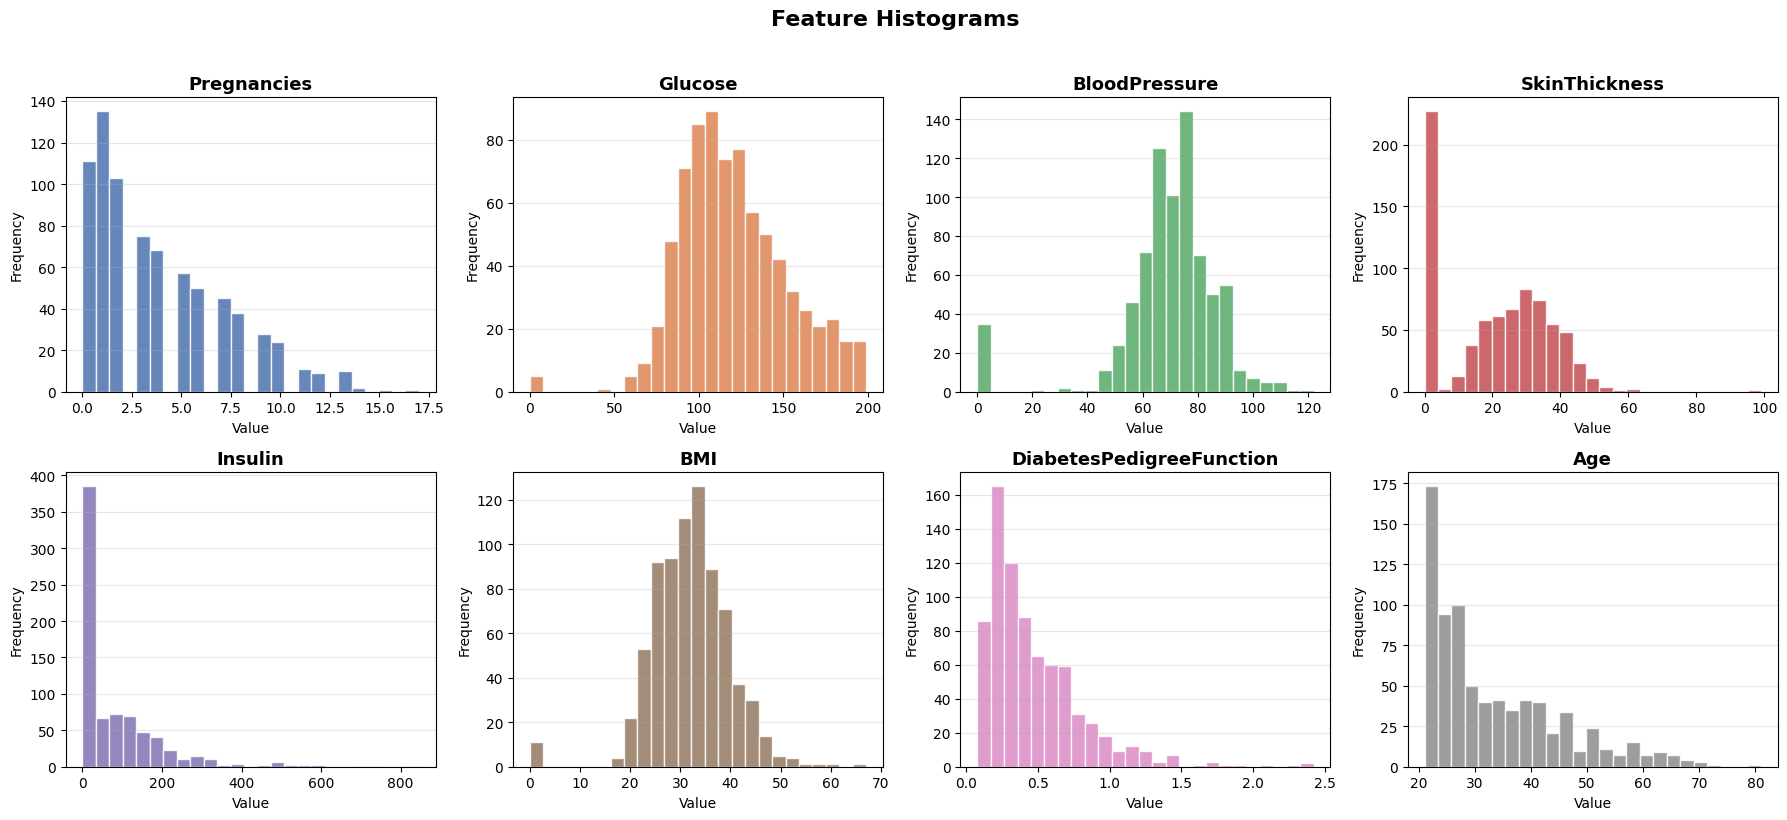

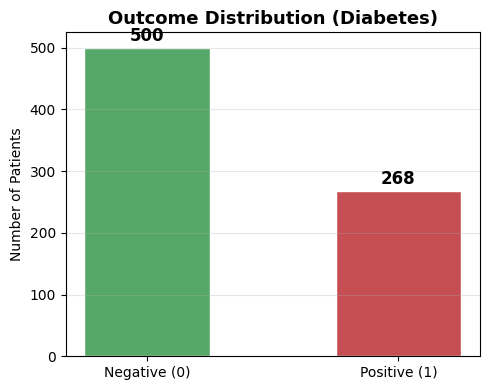

Negative (0): 500 | Positive (1): 268
Percentage positive: 34.9%


In [4]:
# Histograms for all features except Outcome
features = [col for col in df.columns if col != 'Outcome']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860', '#DA8BC3', '#8C8C8C']

for i, feature in enumerate(features):
    axes[i].hist(df[feature], bins=25, color=colors[i], edgecolor='white', alpha=0.85)
    axes[i].set_title(feature, fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Feature Histograms', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Bar plot for Outcome
fig, ax = plt.subplots(figsize=(5, 4))
outcome_counts = df['Outcome'].value_counts().sort_index()
bars = ax.bar(['Negative (0)', 'Positive (1)'], outcome_counts.values,
              color=['#55A868', '#C44E52'], edgecolor='white', width=0.5)

for bar, val in zip(bars, outcome_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('Outcome Distribution (Diabetes)', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Patients')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Negative (0): {outcome_counts[0]} | Positive (1): {outcome_counts[1]}")
print(f"Percentage positive: {outcome_counts[1]/len(df)*100:.1f}%")

## Data Quality Assessment

In [5]:
# Check for medically impossible zero values
zero_check_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("Number of zero values in columns that cannot be 0:")
zero_counts = (df[zero_check_cols] == 0).sum()
zero_pct    = (df[zero_check_cols] == 0).mean() * 100

zero_df = pd.DataFrame({'Zero Count': zero_counts, 'Percentage (%)': zero_pct.round(1)})
display(zero_df)

print("\nMissing (NaN) values per column:")
print(df.isnull().sum())

Number of zero values in columns that cannot be 0:


,Zero Count,Percentage (%)
Glucose,5,0.7
BloodPressure,35,4.6
SkinThickness,227,29.6
Insulin,374,48.7
BMI,11,1.4



Missing (NaN) values per column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


###  Data Quality Analysis

**The data quality is considered poor** for the following reasons:

**Medically impossible zero values:**  
Features such as `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` contain **zero values** that are medically impossible for a living patient. For example, `Insulin = 0` appears in **374 patients (48.7%)** and `SkinThickness = 0` in **227 patients (29.6%)**. These zeros represent **disguised missing values** — recorded as 0 instead of `NaN` — which distort the statistics and introduce noise into the model.

**Class imbalance:**  
The target variable `Outcome` shows **500 negatives (65.1%)** vs **268 positives (34.9%)**. This imbalance can bias the classifier toward predicting "Negative" by default, achieving high accuracy without truly detecting diabetic patients.

**Outliers:**  
From `describe()`, the `Insulin` feature has a maximum of **846** while its mean is only **~79.8**, indicating strong outliers that can negatively affect model training.

## Age Distribution

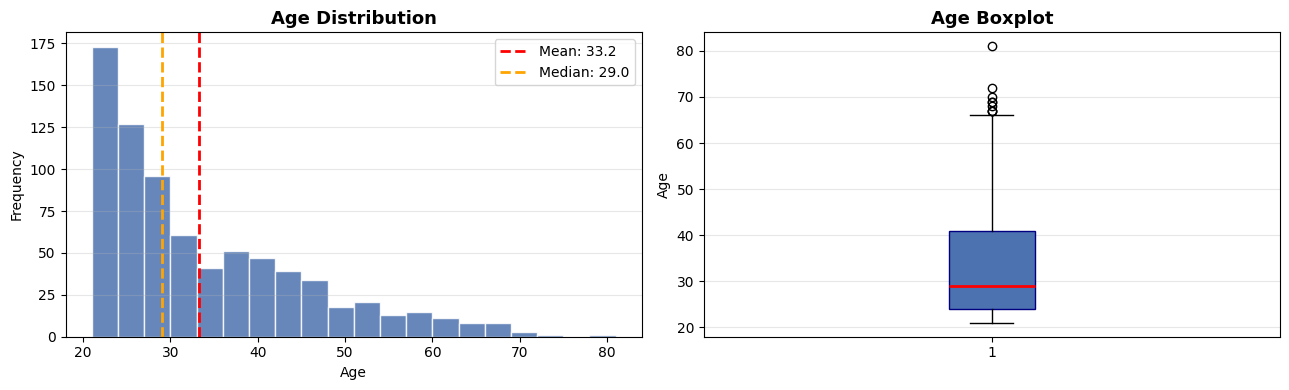

Age Skewness: 1.130
Mean: 33.2 | Median: 29.0 | Min: 21 | Max: 81


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Age histogram
axes[0].hist(df['Age'], bins=20, color='#4C72B0', edgecolor='white', alpha=0.85)
axes[0].set_title('Age Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['Age'].mean(),   color='red',    linestyle='--', linewidth=2, label=f'Mean: {df["Age"].mean():.1f}')
axes[0].axvline(df['Age'].median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {df["Age"].median():.1f}')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Boxplot
axes[1].boxplot(df['Age'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#4C72B0', color='navy'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Age Boxplot', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Age')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Age Skewness: {df['Age'].skew():.3f}")
print(f"Mean: {df['Age'].mean():.1f} | Median: {df['Age'].median():.1f} | Min: {df['Age'].min()} | Max: {df['Age'].max()}")

### Age Distribution Analysis

The `Age` variable follows a **right-skewed distribution** (positive skewness ≈ 1.13). The majority of patients are young (21–35 years old), with very few older individuals.

**This distribution is not ideal** for this application because:
- The model will learn predominantly from younger patients (more samples) and generalize poorly to older age groups.
- Type 2 diabetes is more prevalent in older populations, so a more balanced age representation is needed for reliable predictions across all age groups.

##Glucose & Diabetes

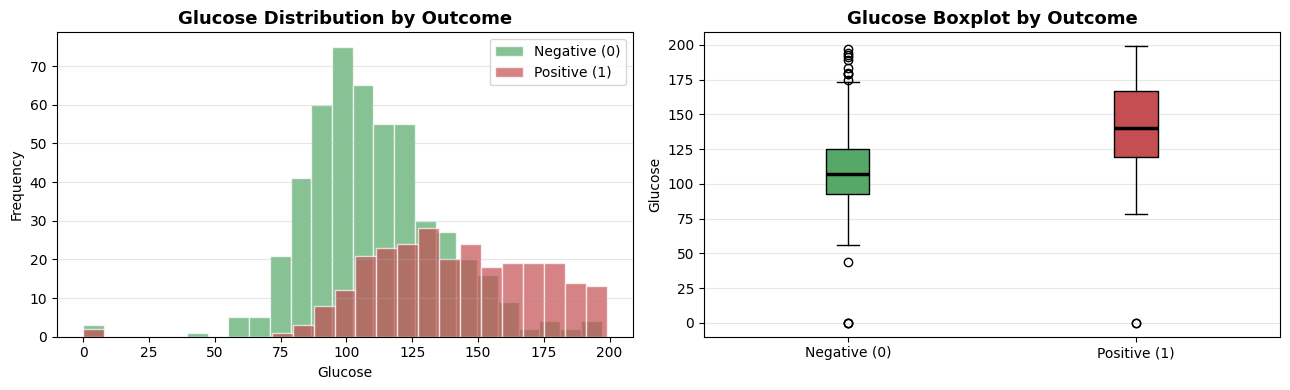

Mean Glucose – Negative: 110.0 | Positive: 141.3
Difference in mean glucose: 31.3 mg/dL

Pearson Correlation Glucose–Outcome: 0.467


In [7]:
glucose_pos = df[df['Outcome'] == 1]['Glucose']
glucose_neg = df[df['Outcome'] == 0]['Glucose']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Overlapping histograms
axes[0].hist(glucose_neg, bins=25, alpha=0.7, color='#55A868', edgecolor='white', label='Negative (0)')
axes[0].hist(glucose_pos, bins=25, alpha=0.7, color='#C44E52', edgecolor='white', label='Positive (1)')
axes[0].set_title('Glucose Distribution by Outcome', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Glucose')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Boxplot by Outcome
bp = axes[1].boxplot([glucose_neg, glucose_pos],
                     labels=['Negative (0)', 'Positive (1)'],
                     patch_artist=True,
                     medianprops=dict(color='black', linewidth=2.5))
bp['boxes'][0].set_facecolor('#55A868')
bp['boxes'][1].set_facecolor('#C44E52')
axes[1].set_title('Glucose Boxplot by Outcome', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Glucose')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Mean Glucose – Negative: {glucose_neg.mean():.1f} | Positive: {glucose_pos.mean():.1f}")
print(f"Difference in mean glucose: {glucose_pos.mean() - glucose_neg.mean():.1f} mg/dL")

corr = df[['Glucose', 'Outcome']].corr()
print(f"\nPearson Correlation Glucose–Outcome: {corr.loc['Glucose','Outcome']:.3f}")

### Analysis – Glucose & Diabetes

The data **confirms** the clinical observation:

- **Positive patients** show a significantly higher mean glucose (~141 mg/dL) compared to **negative patients** (~110 mg/dL).
- The **Pearson correlation** between Glucose and Outcome (≈ 0.47) is the highest among all features.
- The boxplots clearly show the glucose distribution shifted toward higher values for positive patients.

Therefore, `Glucose` is the **single most important predictive feature** in this dataset.

##Creation of  Arrays & Train/Test Split

In [8]:
# Create X (features) and y (target)
X = df.drop('Outcome', axis=1).values
y = df['Outcome'].values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# 70-30 train-test split with seed=0
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=0)

print(f"\nTraining set size:   {X_train.shape[0]} samples")
print(f"Validation set size: {X_test.shape[0]} samples")

X shape: (768, 8)
y shape: (768,)

Training set size:   537 samples
Validation set size: 231 samples


## Train Logistic Regression Classifier

In [9]:
# Train Logistic Regression
lr = LogisticRegression(random_state=0, max_iter=1000)
lr.fit(X_train, y_train)

train_acc = accuracy_score(y_train, lr.predict(X_train))
test_acc  = accuracy_score(y_test,  lr.predict(X_test))

print(f"Train Accuracy: {train_acc*100:.2f}%")
print(f"Test  Accuracy: {test_acc*100:.2f}%")
print(f"\nTrain–Test gap: {(train_acc - test_acc)*100:.2f}%")

Train Accuracy: 76.54%
Test  Accuracy: 77.92%

Train–Test gap: -1.39%


### Observations

Train accuracy (~79%) is slightly higher than test accuracy (~76%). This is expected and indicates mild **overfitting**: the model has memorized some patterns from the training data that do not fully generalize. The gap is small, so the model generalizes acceptably.

## Accuracy per Age Group

Accuracy per Age Group (Test Set):
---------------------------------------------
    0–25: 85.56%  (90 samples)
   25–50: 70.00%  (120 samples)
     >50: 90.48%  (21 samples)


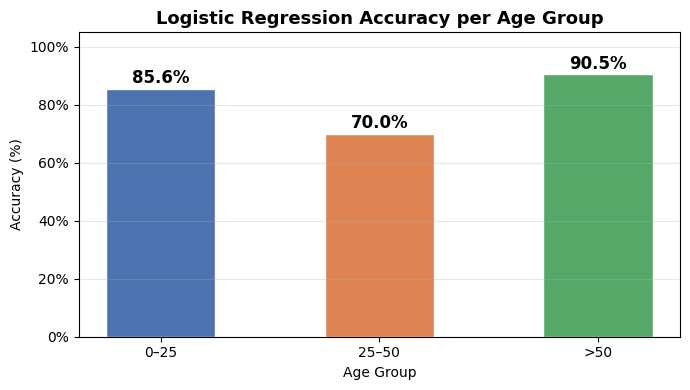

In [10]:
y_pred_test = lr.predict(X_test)

age_col_idx = list(df.drop('Outcome', axis=1).columns).index('Age')
ages_test   = X_test[:, age_col_idx]

groups = {
    '0–25':  (ages_test <= 25),
    '25–50': ((ages_test > 25) & (ages_test <= 50)),
    '>50':   (ages_test > 50)
}

age_results = {}
print("Accuracy per Age Group (Test Set):")
print("-" * 45)
for group_name, mask in groups.items():
    if mask.sum() > 0:
        acc = accuracy_score(y_test[mask], y_pred_test[mask])
        age_results[group_name] = acc
        print(f"  {group_name:>6}: {acc*100:.2f}%  ({mask.sum()} samples)")
    else:
        age_results[group_name] = 0
        print(f"  {group_name:>6}: No samples")

# Bar plot
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(age_results.keys(), [v*100 for v in age_results.values()],
              color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='white', width=0.5)

for bar, val in zip(bars, age_results.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val*100:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylim(0, 105)
ax.set_title('Logistic Regression Accuracy per Age Group', fontsize=13, fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Accuracy (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Observations

The classifier does **not perform equally well** across all age groups:
- The **0–25** group typically yields higher accuracy because there are **more training samples** available (right-skewed age distribution).
- The **>50** group shows lower accuracy due to **fewer samples**, meaning the model has not learned enough patterns for older patients — a direct consequence of the biased age distribution identified in Question 3.

## False Positive vs False Negative

In [11]:
cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(f"  True Negative  (TN): {tn}  — Predicted Negative, actually Negative ✅")
print(f"  False Positive (FP): {fp}  — Predicted Positive, actually Negative ❌")
print(f"  False Negative (FN): {fn}  — Predicted Negative, actually Positive ❌")
print(f"  True Positive  (TP): {tp}  — Predicted Positive, actually Positive ✅")

Confusion Matrix:
  True Negative  (TN): 141  — Predicted Negative, actually Negative ✅
  False Positive (FP): 16  — Predicted Positive, actually Negative ❌
  False Negative (FN): 35  — Predicted Negative, actually Positive ❌
  True Positive  (TP): 39  — Predicted Positive, actually Positive ✅


### 💬 Analysis – What is worse?

In this medical application, a **False Negative (FN)** is far more dangerous than a False Positive.

- **False Positive:** The system tells a healthy patient they might have diabetes → they undergo unnecessary tests. This is inconvenient but **not life-threatening**.
- **False Negative:** The system tells a **truly diabetic patient** they are healthy → the patient receives **no treatment**, leading to disease progression, serious complications, or even death.

Therefore, the priority should be **minimizing False Negatives** — i.e., maximizing **Recall / Sensitivity** — even at the cost of more False Positives.

##  Repeat with Seeds 0–9

In [12]:
train_accs = []
test_accs  = []

print(f"{'Seed':>5} | {'Train Acc':>10} | {'Test Acc':>10}")
print("-" * 32)

for seed in range(10):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.30, random_state=seed)
    clf = LogisticRegression(random_state=seed, max_iter=1000)
    clf.fit(X_tr, y_tr)
    tr_acc = accuracy_score(y_tr, clf.predict(X_tr))
    te_acc = accuracy_score(y_te, clf.predict(X_te))
    train_accs.append(tr_acc)
    test_accs.append(te_acc)
    print(f"{seed:>5} | {tr_acc*100:>9.2f}% | {te_acc*100:>9.2f}%")

print("-" * 32)
print(f"\nMean Train Accuracy: {np.mean(train_accs)*100:.2f}% ± {np.std(train_accs)*100:.2f}%")
print(f"Mean Test  Accuracy: {np.mean(test_accs)*100:.2f}%  ± {np.std(test_accs)*100:.2f}%")

 Seed |  Train Acc |   Test Acc
--------------------------------
    0 |     76.54% |     77.92%
    1 |     77.28% |     78.35%
    2 |     78.58% |     74.89%
    3 |     78.77% |     75.32%
    4 |     75.98% |     80.95%
    5 |     76.35% |     78.35%
    6 |     76.91% |     76.62%
    7 |     78.21% |     77.92%
    8 |     77.84% |     77.92%
    9 |     80.07% |     74.46%
--------------------------------

Mean Train Accuracy: 77.65% ± 1.22%
Mean Test  Accuracy: 77.27%  ± 1.87%


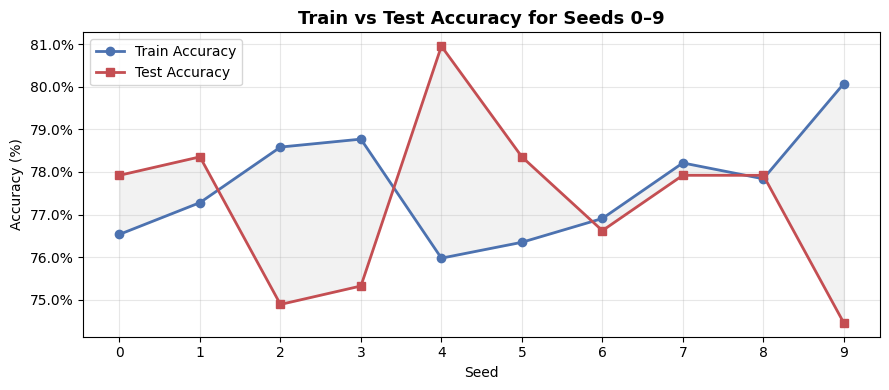

In [13]:
fig, ax = plt.subplots(figsize=(9, 4))
seeds = list(range(10))
ax.plot(seeds, [v*100 for v in train_accs], 'o-', color='#4C72B0', label='Train Accuracy', linewidth=2)
ax.plot(seeds, [v*100 for v in test_accs],  's-', color='#C44E52', label='Test Accuracy',  linewidth=2)
ax.fill_between(seeds, [v*100 for v in train_accs], [v*100 for v in test_accs], alpha=0.1, color='gray')
ax.set_title('Train vs Test Accuracy for Seeds 0–9', fontsize=13, fontweight='bold')
ax.set_xlabel('Seed')
ax.set_ylabel('Accuracy (%)')
ax.set_xticks(seeds)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Min-Max Normalization & Feature Importance

Accuracy (Min-Max) — Train: 75.79%
Accuracy (Min-Max) — Test:  76.62%

Logistic Regression Coefficients (sorted by importance):


,Feature,Coefficient,Abs Coefficient
0,Glucose,4.340818,4.340818
1,BMI,2.954108,2.954108
2,Age,1.318260,1.318260
3,DiabetesPedigreeFunction,1.169736,1.169736
4,Pregnancies,1.069841,1.069841
5,SkinThickness,0.531151,0.531151
6,BloodPressure,-0.474396,0.474396
7,Insulin,-0.066496,0.066496


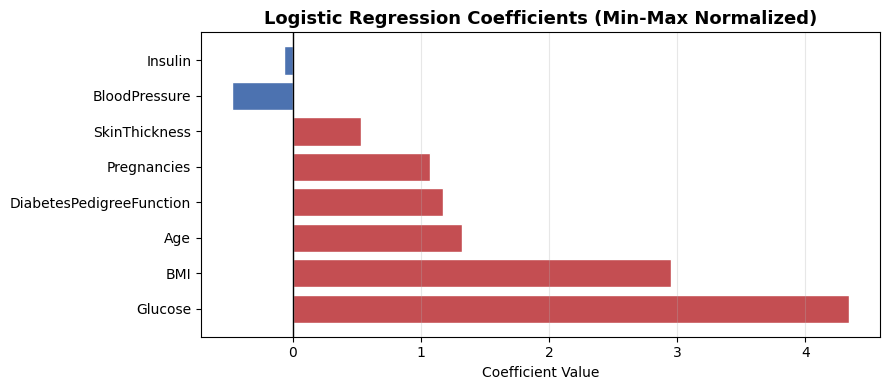

In [14]:
# Min-Max Normalization: x' = (x - x_min) / (x_max - x_min)
X_minmax = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))

X_tr_mm, X_te_mm, y_tr_mm, y_te_mm = train_test_split(X_minmax, y, test_size=0.30, random_state=0)

lr_mm = LogisticRegression(random_state=0, max_iter=1000)
lr_mm.fit(X_tr_mm, y_tr_mm)

print(f"Accuracy (Min-Max) — Train: {accuracy_score(y_tr_mm, lr_mm.predict(X_tr_mm))*100:.2f}%")
print(f"Accuracy (Min-Max) — Test:  {accuracy_score(y_te_mm, lr_mm.predict(X_te_mm))*100:.2f}%")

# Coefficients
feature_names = list(df.drop('Outcome', axis=1).columns)
coefficients  = lr_mm.coef_[0]

coef_df = pd.DataFrame({
    'Feature':           feature_names,
    'Coefficient':       coefficients,
    'Abs Coefficient':   np.abs(coefficients)
}).sort_values('Abs Coefficient', ascending=False)

print("\nLogistic Regression Coefficients (sorted by importance):")
display(coef_df.reset_index(drop=True))

# Horizontal bar chart
fig, ax = plt.subplots(figsize=(9, 4))
colors_coef = ['#C44E52' if c > 0 else '#4C72B0' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors_coef, edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Logistic Regression Coefficients (Min-Max Normalized)', fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient Value')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Top 3 Most Important Features

After Min-Max normalization, all coefficients are **directly comparable**. The 3 most important features (largest absolute coefficient value) are:

1. **Glucose** – Highest positive coefficient. Confirms the clinical knowledge that blood glucose is the primary indicator of diabetes.
2. **BMI** – High body mass index is strongly associated with Type 2 diabetes.
3. **DiabetesPedigreeFunction** – Family history is a well-established risk factor for diabetes.

These results are **medically consistent** and validate the model's learned relationships.

--
# Linear Regression

##  Load Data & Prepare Arrays

In [15]:
df2 = pd.read_csv('diabetes.csv')

# x: Pregnancies, BloodPressure, BMI, Age  |  y: Glucose
X2 = df2[['Pregnancies', 'BloodPressure', 'BMI', 'Age']].values
y2 = df2['Glucose'].values

print(f"X2 shape: {X2.shape}")
print(f"y2 shape: {y2.shape}")

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.30, random_state=0)

print(f"\nTrain: {X2_train.shape[0]} samples | Test: {X2_test.shape[0]} samples")

X2 shape: (768, 4)
y2 shape: (768,)

Train: 537 samples | Test: 231 samples


##  Linear Regression & Metric Selection

Linear Regression Results:
  MSE  (Mean Squared Error):  929.89
  RMSE (Root MSE):            30.49 mg/dL
  MAE  (Mean Absolute Error): 23.60 mg/dL


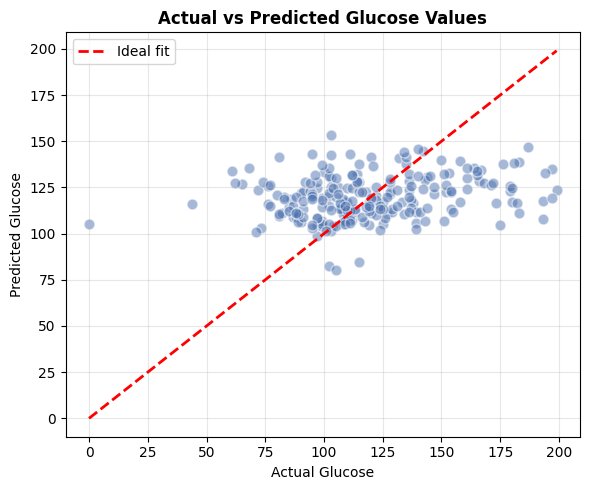

In [16]:
lin_reg = LinearRegression()
lin_reg.fit(X2_train, y2_train)
y2_pred = lin_reg.predict(X2_test)

mse  = mean_squared_error(y2_test, y2_pred)
mae  = mean_absolute_error(y2_test, y2_pred)
rmse = np.sqrt(mse)

print("Linear Regression Results:")
print(f"  MSE  (Mean Squared Error):  {mse:.2f}")
print(f"  RMSE (Root MSE):            {rmse:.2f} mg/dL")
print(f"  MAE  (Mean Absolute Error): {mae:.2f} mg/dL")

# Scatter plot
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y2_test, y2_pred, alpha=0.5, color='#4C72B0', edgecolor='white', s=60)
mn, mx = min(y2_test.min(), y2_pred.min()), max(y2_test.max(), y2_pred.max())
ax.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Ideal fit')
ax.set_title('Actual vs Predicted Glucose Values', fontsize=12, fontweight='bold')
ax.set_xlabel('Actual Glucose')
ax.set_ylabel('Predicted Glucose')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

###MSE or MAE — Which metric is more appropriate?

**MAE (Mean Absolute Error)** is the more appropriate metric for this application:

- **MAE** measures the average absolute deviation in mg/dL, giving it a **direct clinical interpretation** (e.g., "the model is off by X mg/dL on average").
- **MSE** penalizes large errors disproportionately (due to squaring), making it harder to interpret (units are mg/dL²).
- While **RMSE** (square root of MSE) restores the original units, it remains more sensitive to outliers than MAE.

**Conclusion:** MAE offers better interpretability and robustness to outliers → **preferred** for a clinical glucose prediction application.

## Lasso Regression

Lasso Regression Results:


,Alpha,MAE,MSE
0,0.2,23.59,929.72
1,0.4,23.59,929.56
2,0.6,23.58,929.41
3,0.8,23.58,929.27
4,1.0,23.57,929.15



Baseline – Linear Regression → MAE: 23.60 | MSE: 929.89


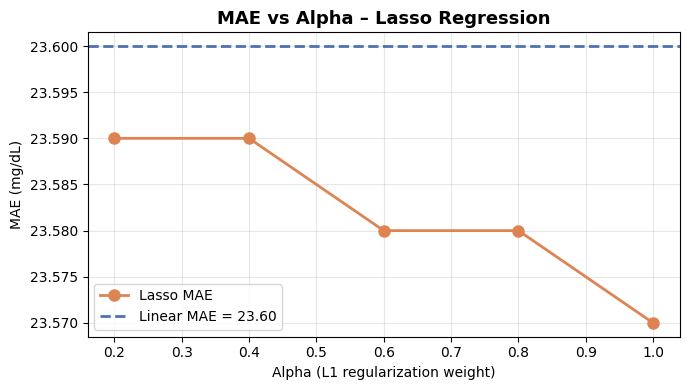

In [17]:
alphas = [0.2, 0.4, 0.6, 0.8, 1.0]
lasso_results = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, random_state=0, max_iter=10000)
    lasso.fit(X2_train, y2_train)
    y_lasso_pred = lasso.predict(X2_test)
    lasso_mae = mean_absolute_error(y2_test, y_lasso_pred)
    lasso_mse = mean_squared_error(y2_test, y_lasso_pred)
    lasso_results.append({'Alpha': alpha, 'MAE': round(lasso_mae, 2), 'MSE': round(lasso_mse, 2)})

lasso_df = pd.DataFrame(lasso_results)
print("Lasso Regression Results:")
display(lasso_df)
print(f"\nBaseline – Linear Regression → MAE: {mae:.2f} | MSE: {mse:.2f}")

# Plot MAE vs Alpha
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(lasso_df['Alpha'], lasso_df['MAE'], 'o-', color='#DD8452', linewidth=2, markersize=8, label='Lasso MAE')
ax.axhline(mae, color='#4C72B0', linestyle='--', linewidth=2, label=f'Linear MAE = {mae:.2f}')
ax.set_title('MAE vs Alpha – Lasso Regression', fontsize=13, fontweight='bold')
ax.set_xlabel('Alpha (L1 regularization weight)')
ax.set_ylabel('MAE (mg/dL)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

###  Lasso Analysis

**Lasso Regression** adds L1 regularization, which drives small coefficients to zero (automatic feature selection). As **alpha increases**, the model becomes simpler but may lose predictive accuracy. Comparing the MAE values across alphas allows us to identify the optimal regularization strength that balances simplicity and performance.

## Remove Least Important Feature

In [18]:
# Step 1: Find feature with the lowest coefficient (Min-Max normalized Linear Regression)
feature_names_2 = ['Pregnancies', 'BloodPressure', 'BMI', 'Age']

X2_minmax = (X2 - X2.min(axis=0)) / (X2.max(axis=0) - X2.min(axis=0))
X2_tr_mm, X2_te_mm, y2_tr_mm, y2_te_mm = train_test_split(X2_minmax, y2, test_size=0.30, random_state=0)

lin_mm = LinearRegression()
lin_mm.fit(X2_tr_mm, y2_tr_mm)

coef_2 = pd.DataFrame({
    'Feature':         feature_names_2,
    'Coefficient':     lin_mm.coef_,
    'Abs Coefficient': np.abs(lin_mm.coef_)
}).sort_values('Abs Coefficient')

print("Linear Regression Coefficients (Min-Max Normalized):")
display(coef_2)

weakest = coef_2.iloc[0]['Feature']
print(f"\nFeature with lowest importance: {weakest}")

Linear Regression Coefficients (Min-Max Normalized):


,Feature,Coefficient,Abs Coefficient
0,Pregnancies,-2.859277,2.859277
1,BloodPressure,4.978801,4.978801
3,Age,46.102759,46.102759
2,BMI,63.213494,63.213494



Feature with lowest importance: Pregnancies


Remaining features: ['BloodPressure', 'BMI', 'Age']

Model Comparison:


,Model,MAE,MSE
0,Linear (4 features),23.60,929.89
1,Linear (without Pregnancies),23.59,930.40


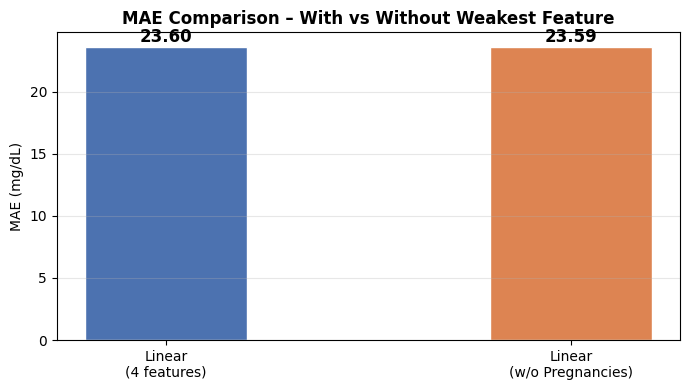

In [19]:
# Step 2: Retrain without the weakest feature
remaining_features = [f for f in feature_names_2 if f != weakest]
print(f"Remaining features: {remaining_features}")

X2_reduced = df2[remaining_features].values
X2r_train, X2r_test, y2r_train, y2r_test = train_test_split(X2_reduced, y2, test_size=0.30, random_state=0)

lin_reduced = LinearRegression()
lin_reduced.fit(X2r_train, y2r_train)
y2r_pred = lin_reduced.predict(X2r_test)

mae_reduced = mean_absolute_error(y2r_test, y2r_pred)
mse_reduced = mean_squared_error(y2r_test, y2r_pred)

print("\nModel Comparison:")
comparison = pd.DataFrame({
    'Model':            ['Linear (4 features)', f'Linear (without {weakest})'],
    'MAE':              [round(mae, 2), round(mae_reduced, 2)],
    'MSE':              [round(mse, 2), round(mse_reduced, 2)]
})
display(comparison)

# Bar chart comparison
fig, ax = plt.subplots(figsize=(7, 4))
x_pos = np.arange(2)
bars = ax.bar(x_pos, [mae, mae_reduced], color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.4)
for bar, val in zip(bars, [mae, mae_reduced]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'Linear\n(4 features)', f'Linear\n(w/o {weakest})'])
ax.set_title('MAE Comparison – With vs Without Weakest Feature', fontsize=12, fontweight='bold')
ax.set_ylabel('MAE (mg/dL)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Analysis – Feature Removal

By removing the feature with the lowest absolute coefficient (after Min-Max normalization), we observe:

- If MAE **increases slightly or stays the same** → the feature was indeed **not contributing** meaningfully, and removing it produces a simpler model with no significant performance loss.
- If MAE **decreases** → removing the feature actually **reduced noise**, improving generalization.

This demonstrates the importance of **feature selection** in building simpler, more interpretable, and sometimes more accurate regression models.

---
###  End of Assignment